<h1 align="center">EN3160 Assignment 1</h1>
<h2 align="center">Intensity Transformations and Neighborhood Filtering</h2>

**Name:** Anthony C.S.B.  
**Index Number:** 230045X

<h2 align="left">Question 1</h2>

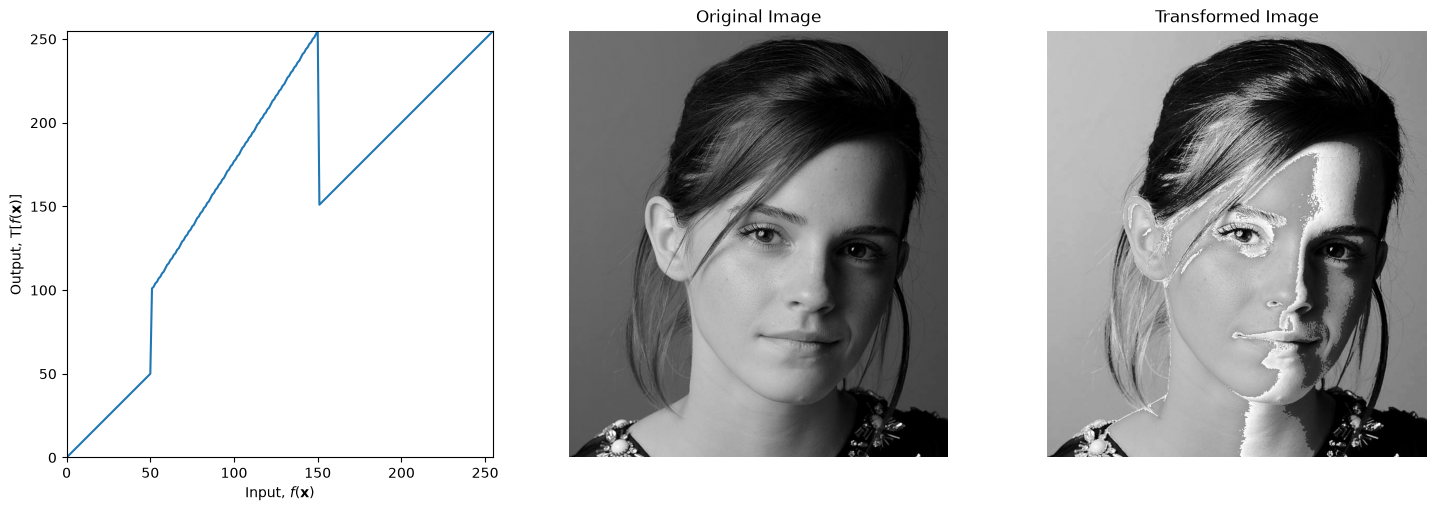

In [24]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def  intensity_transform(im, breakpoints):

    #First window is handled differently from the rest
    transform  = np.linspace(breakpoints[0,1],breakpoints[1,1],breakpoints[1,0]-breakpoints[0,0]+1).astype('uint8')
        
    for i in range(2,len(breakpoints)):
        if (breakpoints[i-1,1]<255):
            window = np.linspace(breakpoints[i-1,1]+1,breakpoints[i,1],breakpoints[i,0]-breakpoints[i-1,0]).astype('uint8')
            transform = np.concatenate((transform, window), axis=0).astype('uint8')   
        else:
            window = np.linspace(breakpoints[i-1,1],breakpoints[i,1],breakpoints[i,0]-breakpoints[i-1,0]).astype('uint8')
            transform = np.concatenate((transform, window), axis=0).astype('uint8')   
      
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].plot(transform)
    ax[0].set_xlabel(r'Input, $f(\mathbf{x})$')
    ax[0].set_ylabel(r'Output, $\mathrm{T}[f(\mathbf{x})]$')
    ax[0].set_xlim(0,255)
    ax[0].set_ylim(0,255)
    ax[0].set_aspect('equal') 

    img_original = cv.imread(im, cv.IMREAD_GRAYSCALE)
    assert img_original is not None

    image_transformed = cv.LUT(img_original, transform)
    
    ax[1].imshow(img_original, cmap='gray')
    ax[1].set_title('Original Image')
    ax[1].axis('off')

    ax[2].imshow(image_transformed, cmap='gray')
    ax[2].set_title('Transformed Image')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show(block=False)

intensity_transform("emma.jpg", np.array([(0,0),(50,50),(50,100),(150,255),(150,150),(255,255)]))


<h2 align="left">Question 2</h2>

After searching how gray and white matter appear in a proton density image, I learnt the following and intensity windowing was applied accordingly.
- Gray Matter: Appears lighter or brighter gray because it has a higher proton (water) density and higher signal intensity.
- White Matter: Appears darker gray because it contains more myelin and less free water, resulting in a lower signal.
- Cerebrospinal Fluid (CSF): Appears very bright (hyperintense) due to its high water content - A very bright coloured, butterfly shaped patch which appears right in the middle of the given image. 

To determine the correct intensity ranges of gray and white matter to apply appropriate intensity windowing, I plotted the histogram of the given image first and then I compared it with a reference image of normal proton density image with named regions to clarify the intensity ranges.

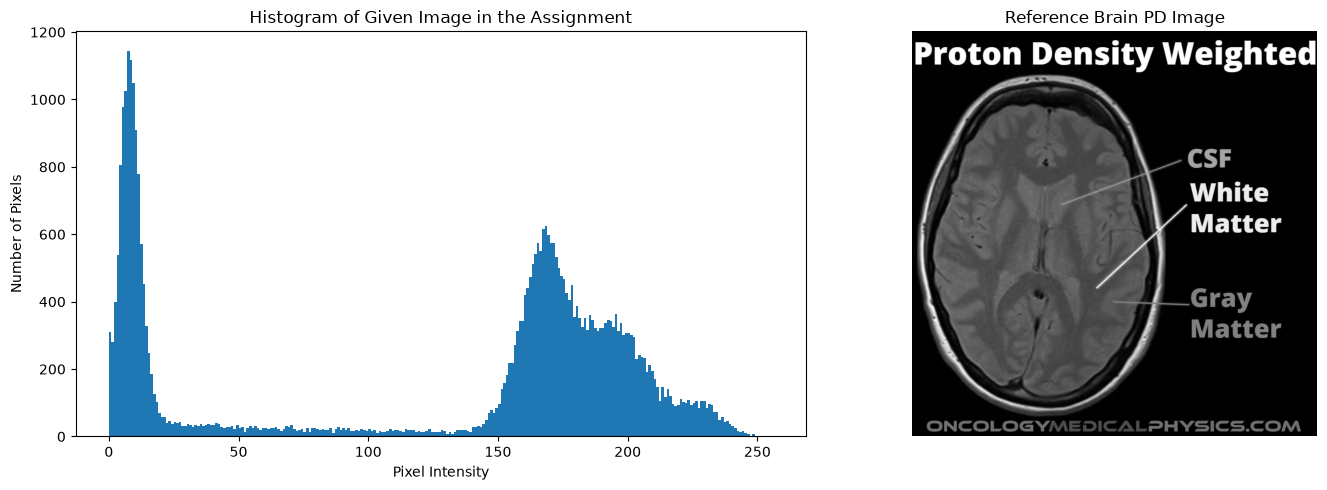

In [25]:
img1 = cv.imread("brain_PD_slice.jpg", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("Proton-Density-Weighted.jpg", cv.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(img1.ravel(), bins=256, range=[0, 256])
ax[0].set_xlabel("Pixel Intensity")
ax[0].set_ylabel("Number of Pixels")
ax[0].set_title("Histogram of Given Image in the Assignment")

ax[1].imshow(img2, cmap='gray')
ax[1].set_title("Reference Brain PD Image")
ax[1].axis('off')

plt.tight_layout()
plt.show(block=False)

According to above histogram and reference image:
- White Matter - Intensity range of 145-180
- Gray Matter - Intensity range of 180-215

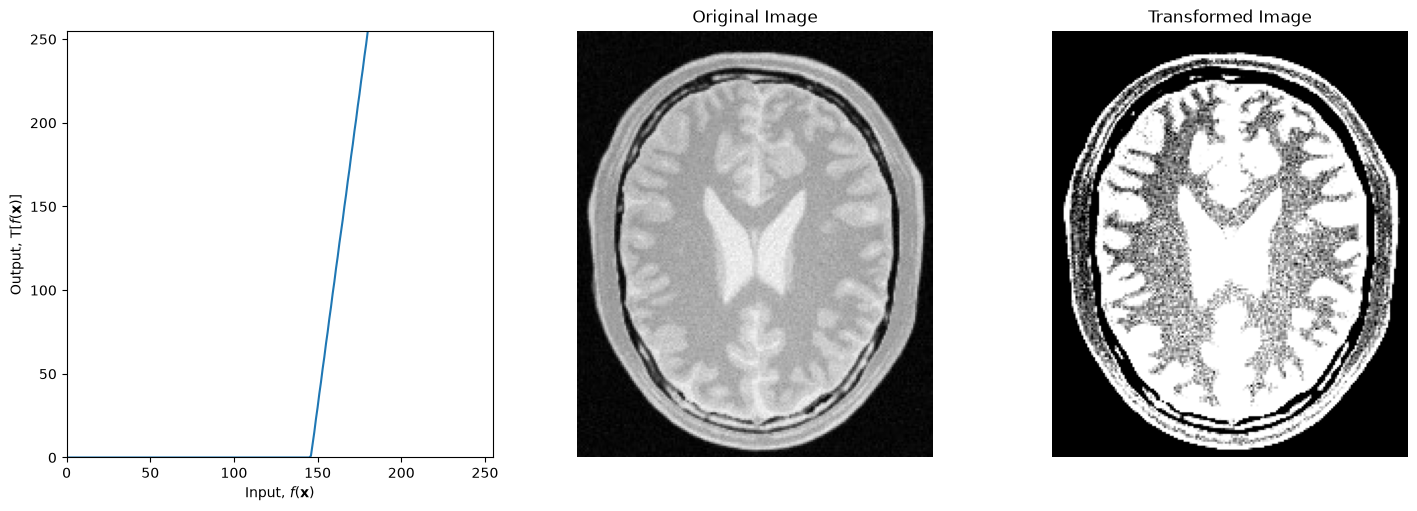

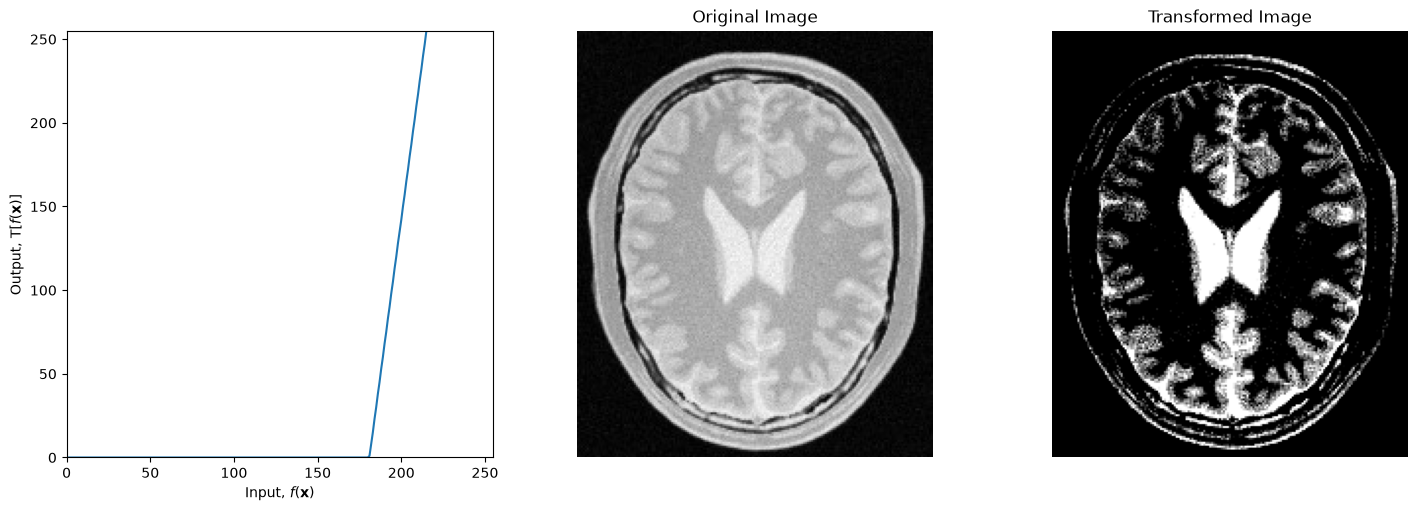

In [26]:
intensity_transform("brain_PD_slice.jpg", np.array([(0,0), (145,0), (180,255), (255,255)])) #White Matter - first row of images
intensity_transform("brain_PD_slice.jpg", np.array([(0,0), (180,0), (215,255), (255,255)])) #Gray Matter - second row of images

<h2 align="left">Question 3</h2>

In this question, L, a and b planes are lightness, Green-Red Axis and Blue-Yellow Axis respectively. Only L plane is used for gamma correction to change only the brightness and keep colours untouched. For the gamma value, **0.5** is used because the given image has more dark pixels and the variation of dark pixels are not very sensitive to bare eye.

- $\gamma$ = 0.5

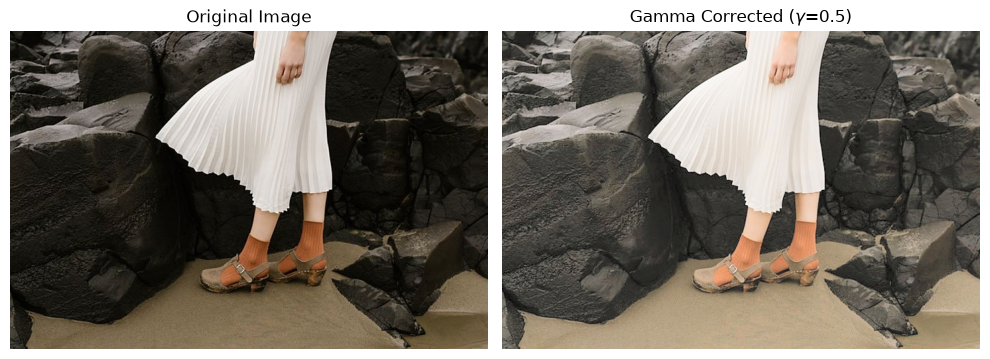

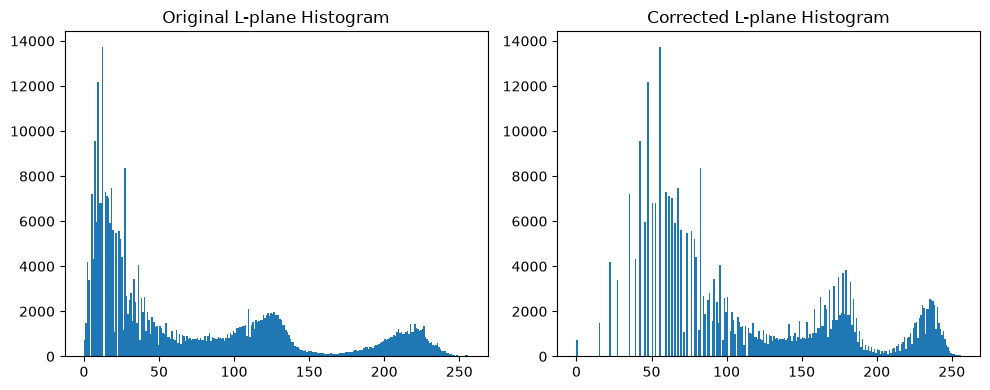

In [27]:
img_bgr = cv.imread('lady.jpg') 
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)
gamma = 0.5
table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
L_corrected = cv.LUT(L, table)

img_lab_corrected = cv.merge((L_corrected, a, b))
img_corrected_rgb = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_corrected_rgb)
plt.title(rf'Gamma Corrected ($\gamma$={gamma})')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(L.ravel(), 256, range=[0, 256])
plt.title('Original L-plane Histogram')

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), 256, range=[0, 256])
plt.title('Corrected L-plane Histogram')
plt.tight_layout()
plt.show()

<h2 align="left">Question 4</h2>

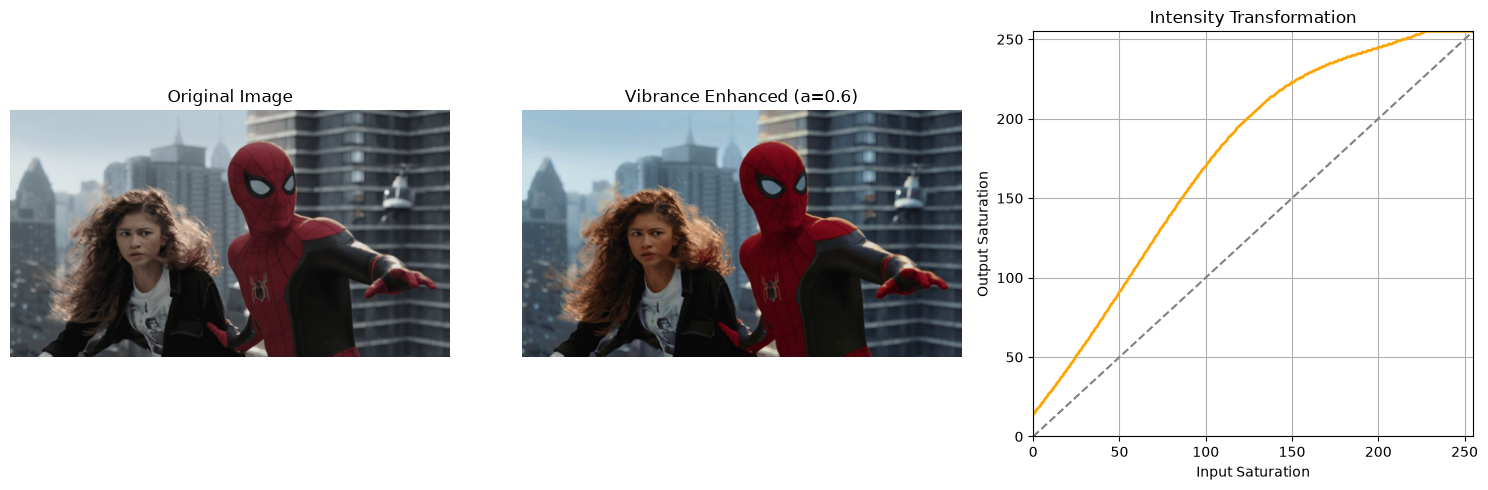

In [28]:
img_bgr = cv.imread('spider_man.jpg') 
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

h, s, v = cv.split(img_hsv)
a = 0.6    
sigma = 70
x = np.arange(256) 

curve = x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))
transform_curve = np.clip(curve, 0, 255).astype(np.uint8)

s_enhanced = cv.LUT(s, transform_curve)
img_hsv_enhanced = cv.merge((h, s_enhanced, v))
img_enhanced_rgb = cv.cvtColor(img_hsv_enhanced, cv.COLOR_HSV2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_enhanced_rgb)
plt.title(f'Vibrance Enhanced (a={a})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(x, transform_curve, color='orange', linewidth=2)
plt.plot(x, x, linestyle='--', color='gray') # Reference line y=x
plt.title('Intensity Transformation')
plt.xlabel('Input Saturation')
plt.ylabel('Output Saturation')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

<h2 align="left">Question 5</h2>

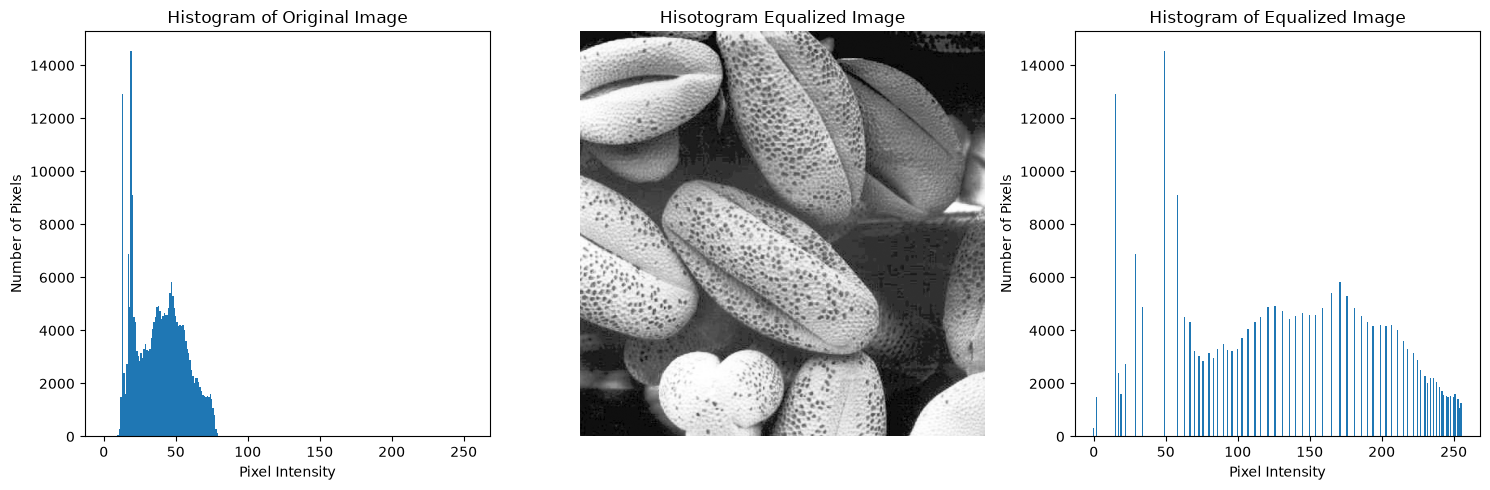

In [29]:
def histogram_equalization(im):

    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    height,width = img.shape[:2]
    hist1 = cv.calcHist([img], [0], None, [256], [0,256])

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].bar(np.arange(256), hist1.flatten(), width=1)
    ax[0].set_xlabel("Pixel Intensity")
    ax[0].set_ylabel("Number of Pixels")
    ax[0].set_title("Histogram of Original Image")

    cdf = 0
    mapping = np.arange(256)
    for k in range(256):
        cdf += hist1[k]
        mapping[k] = round(255*cdf/(height*width))

    equalized_img = mapping[img].astype(np.uint8)
    ax[1].imshow(equalized_img, cmap='gray')
    ax[1].set_title("Hisotogram Equalized Image")
    ax[1].axis('off')

    hist2 = cv.calcHist([equalized_img], [0], None, [256], [0,256])
    ax[2].bar(np.arange(256), hist2.flatten(), width=1)
    ax[2].set_xlabel("Pixel Intensity")
    ax[2].set_ylabel("Number of Pixels")
    ax[2].set_title("Histogram of Equalized Image")

    plt.tight_layout()
    plt.show(block=False)
    
    
histogram_equalization("shells.jpg")